In [6]:
'''Open Text files and pull out stim times'''

import os
import sys
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib widget

In [10]:

def get_stim_times(dir_path):

    stim_times_data = {}
    # Check if the file exists
    for path, subdirs, files in os.walk(dir_path):
        for name in files:
            #name is every before the .dat
            if name.endswith('.dat'):
                current_name = name.split('.')[0]
                data_file = os.path.join(path, name)
                stim_times_data[current_name] = {}

            #Reading the file
                with open(data_file) as f:
                    lines = f.readlines()

                # Parsing the data
                data_dict = {}
                current_channel = None
                current_data = []

                # Iterating through each line to parse the data
                for line in lines:
                    line = line.strip()
                    if line.startswith('channel:'):
                        if current_channel is not None:
                            # Save the data of the previous channel before starting a new one
                            data_dict[current_channel] = current_data
                        # Extracting the channel number
                        current_channel = line.split(': ')[1]
                        current_data = []
                    elif current_channel is not None and line:  # if there is a current channel and the line is not empty
                        # Splitting the line to extract time and value
                        try:
                            time_value_pair = [float(x) for x in line.split()]
                            current_data.append(time_value_pair)
                        except ValueError:
                            # If conversion to float fails, we skip the line
                            continue

                # Saving the data of the last channel
                if current_channel is not None:
                    data_dict[current_channel] = current_data

                # Now, extract the stim times as described
                stim_times = {}

                for channel, data in data_dict.items():
                    stim_times[f'channel {channel}'] = []
                    # Extracting the time values
                    times = np.array(data)[:, 1] / 1000  # Convert to seconds
                    start_time = times[0]
                
                    stim_onset_idx = np.where(times == 0.1)[0]
                    #starting from the start time get the cumulative sum of the stim onset using np.cumsum
                    cumulative_time = np.cumsum(times)
                    #get the stim onset time
                    stim_times_for_channel = cumulative_time[stim_onset_idx] - 0.1

                    stim_times[f'channel {channel}'] = stim_times_for_channel

                stim_times_data[current_name] = stim_times

    return stim_times_data

In [11]:
#clear all figures
plt.close('all')

In [12]:
# stim_times = get_stim_times('/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/MCII(Before_05_16_2024)')
# stim_times 

In [13]:
def plot_stim_times(folder_path):
    stim_files = get_stim_times(folder_path)
    #plot vertical lines for each stim time for each channel of each cell on seperate figures cooresponding to the file name
    for file_name, stim_times in stim_files.items():
        fig, ax = plt.subplots()
        ax.set_title(file_name)
        for channel, times in stim_times.items():
            print(times)
            ax.vlines(times, 0, 1, label=channel)
        ax.legend()
        # plt.show()



In [20]:
#old_stims_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/MCII(Before_05_16_2024)_dat_files'
# new_stims_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/MCIII(After_05_16_2024)_dat_files'
new_stims_path_2 = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/MCIII(After_05_16_2024)_dat_files_variant_2'

#old_save_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/Before_05_16_2024_stim_protocals'
# new_save_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/After_05_16_2024_stim_protocals'


In [21]:
stim_files = get_stim_times(new_stims_path_2)
stim_files 


{'E_I_Stim_100_ISI_new': {'channel 1': array([500., 600., 700.]),
  'channel 2': array([1500., 1600., 1700.])},
 'E_I_Stim_25_ISI_new': {'channel 1': array([500., 525., 550.]),
  'channel 2': array([1500., 1525., 1550.])},
 'E_I_Stim_50_ISI_new': {'channel 1': array([500., 550., 600.]),
  'channel 2': array([1500., 1550., 1600.])},
 'E_I_Stim_300_ISI_new': {'channel 1': array([ 500.,  800., 1100.]),
  'channel 2': array([1500., 1800., 2100.])},
 'Theta_Burst_MCIII_new_variant_2': {'channel 1': array([ 500.,  510.,  520.,  530.,  540.,  650.,  660.,  670.,  680.,
          690.,  800.,  810.,  820.,  830.,  840.,  950.,  960.,  970.,
          980.,  990., 1100., 1110., 1120., 1130., 1140.]),
  'channel 2': array([ 500.,  510.,  520.,  530.,  540.,  650.,  660.,  670.,  680.,
          690.,  800.,  810.,  820.,  830.,  840.,  950.,  960.,  970.,
          980.,  990., 1100., 1110., 1120., 1130., 1140.])},
 'E_I_Stim_10_ISI_new': {'channel 1': array([500., 510., 520.]),
  'channel 2': a

[500. 600. 700.]
[1500. 1600. 1700.]
[500. 525. 550.]
[1500. 1525. 1550.]
[500. 550. 600.]
[1500. 1550. 1600.]
[ 500.  800. 1100.]
[1500. 1800. 2100.]
[ 500.  510.  520.  530.  540.  650.  660.  670.  680.  690.  800.  810.
  820.  830.  840.  950.  960.  970.  980.  990. 1100. 1110. 1120. 1130.
 1140.]
[ 500.  510.  520.  530.  540.  650.  660.  670.  680.  690.  800.  810.
  820.  830.  840.  950.  960.  970.  980.  990. 1100. 1110. 1120. 1130.
 1140.]
[500. 510. 520.]
[1500. 1510. 1520.]
[500. 550. 600. 650. 700. 750. 800. 850. 900. 950.]
[500. 550.]
[800. 850.]


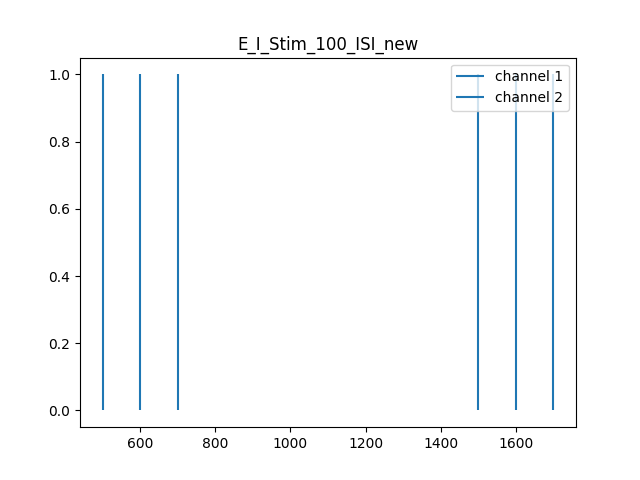

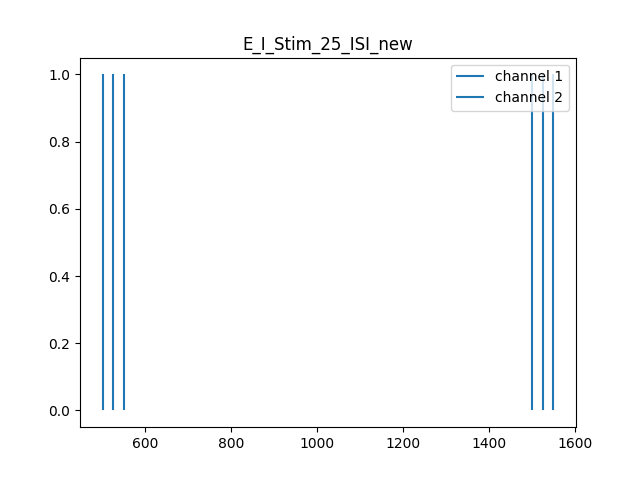

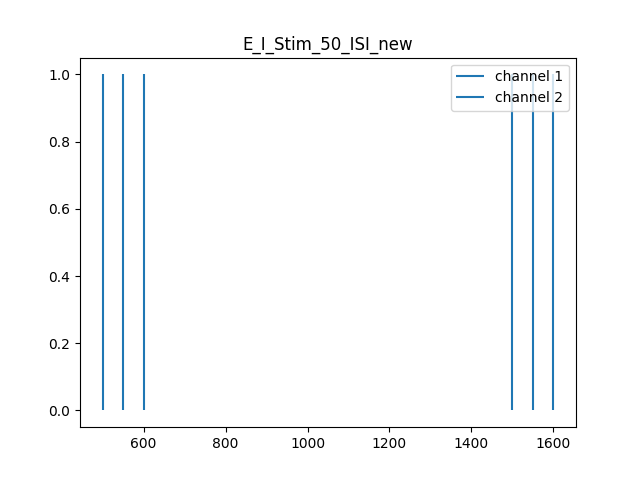

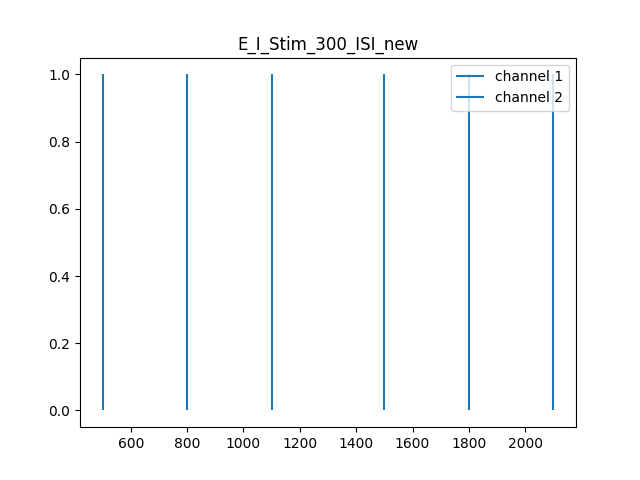

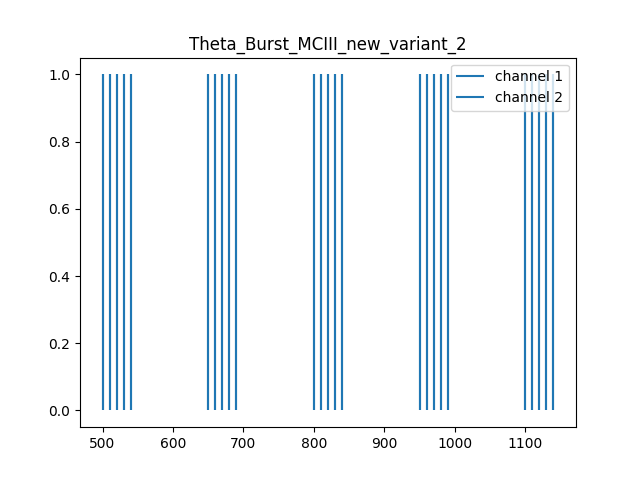

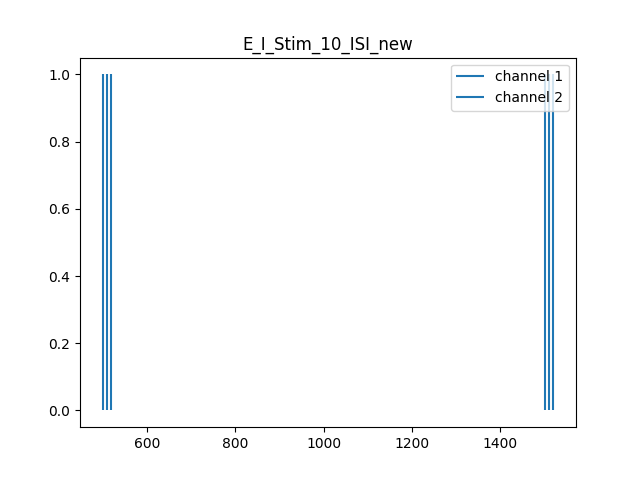

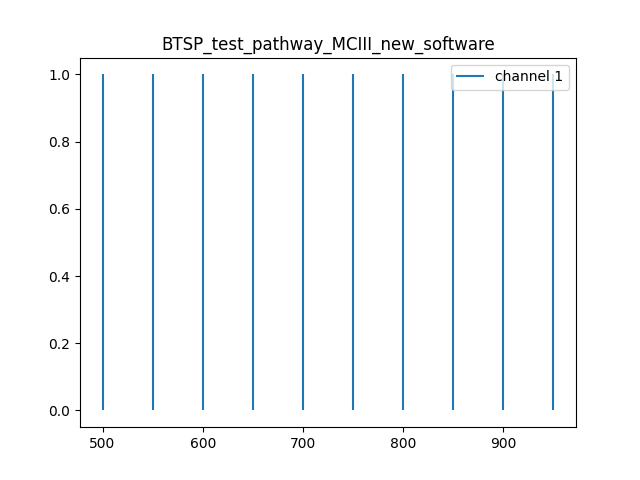

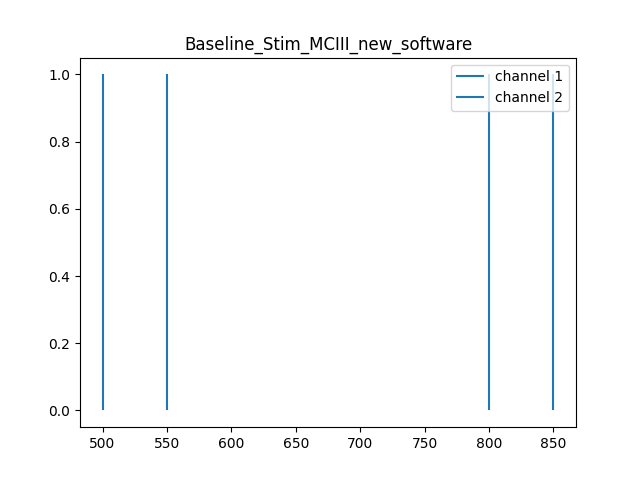

In [22]:
stim_files = get_stim_times(new_stims_path_2)
#plot vertical lines for each stim time for each channel of each cell on seperate figures cooresponding to the file name
for file_name, stim_times in stim_files.items():
    fig, ax = plt.subplots()
    ax.set_title(file_name)
    for channel, times in stim_times.items():
        print(times)
        ax.vlines(times, 0, 1, label=channel)
    ax.legend()

In [25]:
# stim_times = get_stim_times(new_stims_path_2)
# # stim_times

# #convert to a dataframe
# stim_times_df = pd.DataFrame(stim_times)

# # stim_times_df['Theta_Burst_MCII_old'] 

# # #convert to text file
# # stim_times_df['Theta_Burst_MCII_old'].to_csv(old_save_path + '/Theta_Burst_MCII_old.txt', header=None, index=None, sep=' ', mode='a')


# new_save_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/Ephys_Analysis/Updated_Code/Intracellular_Analysis/Stim_Protocal_Files/After_05_16_2024_stim_protocals'

# #save the dataframe to a csv file
# stim_times_df.to_csv(new_save_path + '/stim_times.csv')